# Q1. Bar Chart – Survival Rate by Embarked Port

Matplotlib is building the font cache; this may take a moment.


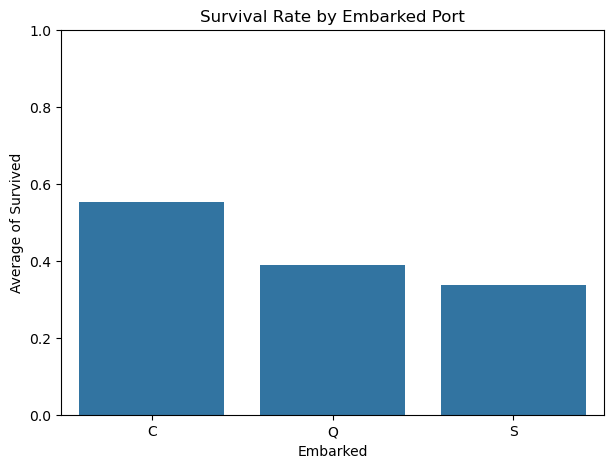

Port with highest survival rate: C
Highest survival rate: 55.36 %


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_dataset.csv")

# Calculate average survival rate for each embarked port
embarked_survival = df.groupby("Embarked")["Survived"].mean()

# Create bar chart
plt.figure(figsize=(7, 5))

sns.barplot(
    x=embarked_survival.index,
    y=embarked_survival.values
)

plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Average of Survived")
plt.ylim(0, 1)

plt.show()

# Identify port with highest survival rate
highest_port = embarked_survival.idxmax()
highest_rate = embarked_survival.max()

print("Port with highest survival rate:", highest_port)
print("Highest survival rate:", round(highest_rate * 100, 2), "%")



# Q2. Create FamilySize Column and Count Plot

In [2]:
# Create new FamilySize column
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Display selected columns
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


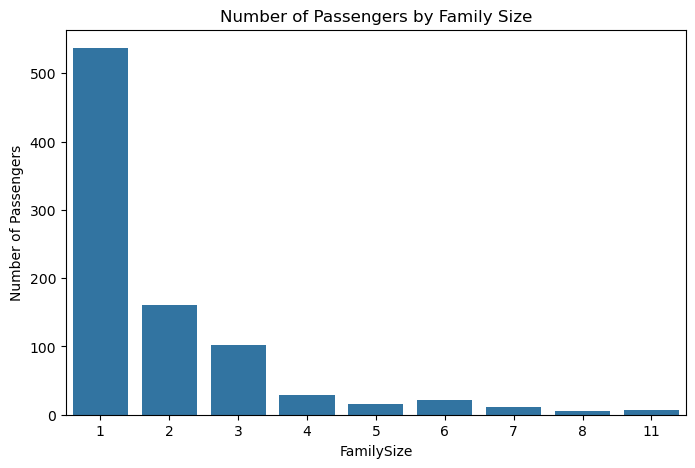

Most common Family Size: 1
Number of passengers: 537


In [3]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="FamilySize"
)

plt.title("Number of Passengers by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Number of Passengers")

plt.show()

# Identify most common family size
most_common_family = df["FamilySize"].mode()[0]
family_count = df["FamilySize"].value_counts().max()

print("Most common Family Size:", most_common_family)
print("Number of passengers:", family_count)

# Q3. Box Plot – Fare by Pclass and Sex

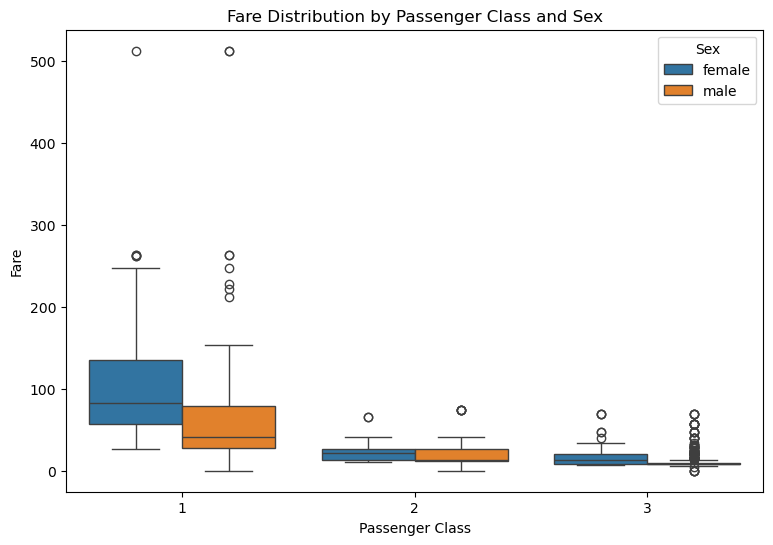

In [4]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Sex"
)

plt.title("Fare Distribution by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Sex")

plt.show()

In [5]:
fare_summary = df.groupby(["Pclass", "Sex"])["Fare"].agg(
    ["mean", "median", "max"]
)

fare_summary

mean    median       max
Pclass Sex                                   
1      female  106.125798  82.66455  512.3292
       male     67.226127  41.26250  512.3292
2      female   21.970121  22.00000   65.0000
       male     19.741782  13.00000   73.5000
3      female   16.118810  12.47500   69.5500
       male     12.661633   7.92500   69.5500

In [6]:
# Find group with highest average fare
highest_avg_group = fare_summary["mean"].idxmax()
highest_avg_fare = fare_summary["mean"].max()

print("Group with highest average fare:", highest_avg_group)
print("Highest average fare:", round(highest_avg_fare, 2))

Group with highest average fare: (np.int64(1), 'female')
Highest average fare: 106.13


# Q4. Line Plot – Average Survival Rate by Family Size

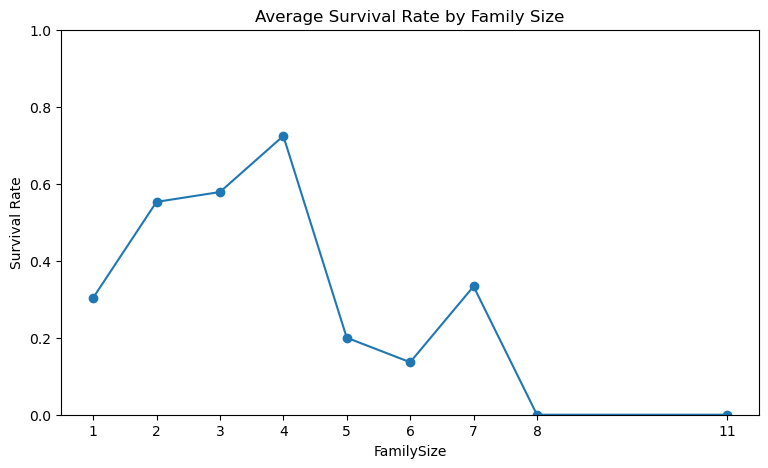

Family size with highest survival rate: 4
Highest survival rate: 72.41 %


In [7]:
# Calculate average survival rate for each family size
family_survival = df.groupby("FamilySize")["Survived"].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    family_survival.index,
    family_survival.values,
    marker="o"
)

plt.title("Average Survival Rate by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(family_survival.index)

plt.show()

# Identify family size with highest survival rate
best_family_size = family_survival.idxmax()
best_survival_rate = family_survival.max()

print("Family size with highest survival rate:", best_family_size)
print("Highest survival rate:", round(best_survival_rate * 100, 2), "%")

# Q5. Passenger Class & Gender Survival Comparison

In [8]:
survival_counts = pd.crosstab(
    [df["Pclass"], df["Sex"]],
    df["Survived"]
)

# Rename columns for better understanding
survival_counts.columns = ["Not Survived", "Survived"]

survival_counts

Not Survived  Survived
Pclass Sex                           
1      female             3        91
       male              77        45
2      female             6        70
       male              91        17
3      female            72        72
       male             300        47

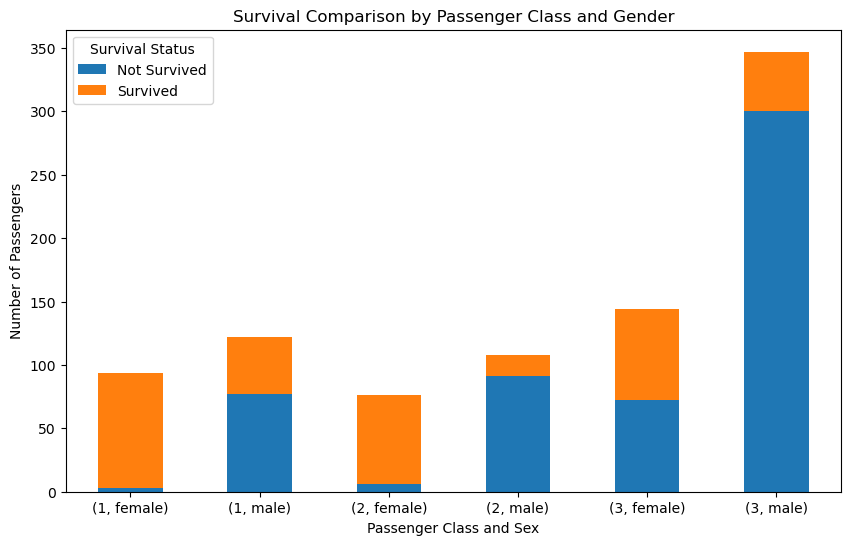

In [9]:
survival_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Survival Comparison by Passenger Class and Gender")
plt.xlabel("Passenger Class and Sex")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Survival Status")

plt.show()

In [10]:
print(survival_counts)

               Not Survived  Survived
Pclass Sex                           
1      female             3        91
       male              77        45
2      female             6        70
       male              91        17
3      female            72        72
       male             300        47
